TypeError: Invalid shape (352,) for image data

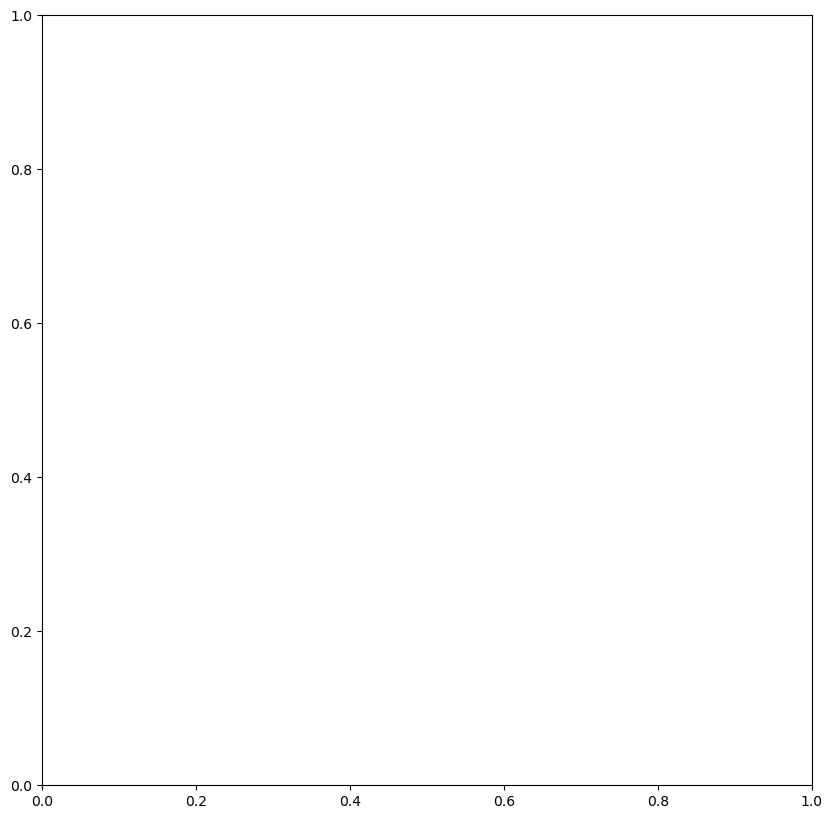

In [15]:
import torch
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 設定運算裝置
device = "cuda" if torch.cuda.is_available() else "cpu"

# 定義本地模型路徑（請將此路徑替換為你自己的本地模型路徑）
local_model_path = "./"

# 1. 從本地載入 CLIPSeg 的處理器與模型
processor = CLIPSegProcessor.from_pretrained(local_model_path, local_files_only=True)
model = CLIPSegForImageSegmentation.from_pretrained(local_model_path, local_files_only=True).to(device)

# 2. 載入圖片和定義文字提示（根據你的需求調整文字描述）
image_path = "./36.jpg"  # 請替換成你的圖片路徑
image = Image.open(image_path).convert("RGB")
text_prompts = ["a photo of a dog doll"]

# 3. 使用處理器對圖片與文字進行預處理
inputs = processor(text=text_prompts, images=image, padding="max_length", return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# 4. 進行推理以獲得分割 mask 的 logits
with torch.no_grad():
    outputs = model(**inputs)

# 5. 對 logits 使用 sigmoid 激活，取得 mask 概率圖
mask_logits = outputs.logits  # shape: [batch_size, num_prompts, height, width]
mask_probs = torch.sigmoid(mask_logits)

# 取第一張圖片、第一個文字提示所對應的 mask
mask = mask_probs[0, 0].cpu().numpy()

# 6. (可選) 進行簡單閾值處理，產生二值化 mask
binary_mask = mask > 0.5

# 7. 視覺化原圖與分割結果
plt.figure(figsize=(10, 10))
# plt.imshow(image)
plt.imshow(binary_mask, alpha=0.5, cmap="jet")
plt.title("CLIPSeg Zero-Shot Segmentation (Local Model)")
plt.axis("off")
plt.show()


outputs.logits.shape: torch.Size([1, 352, 352])


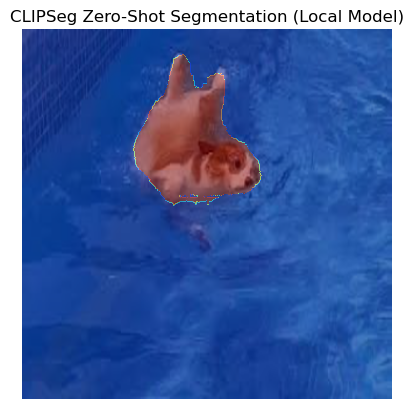

outputs.logits.shape: torch.Size([1, 352, 352])


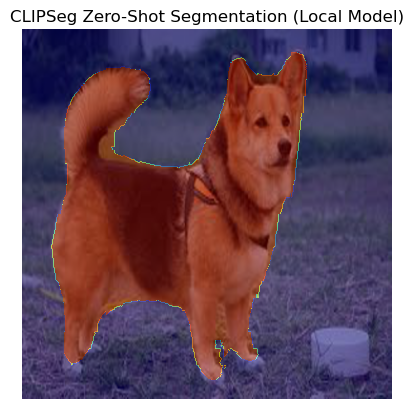

outputs.logits.shape: torch.Size([1, 352, 352])


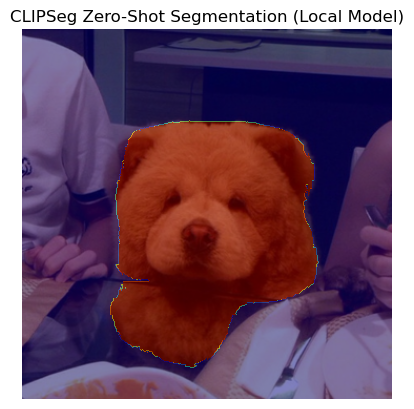

outputs.logits.shape: torch.Size([1, 352, 352])


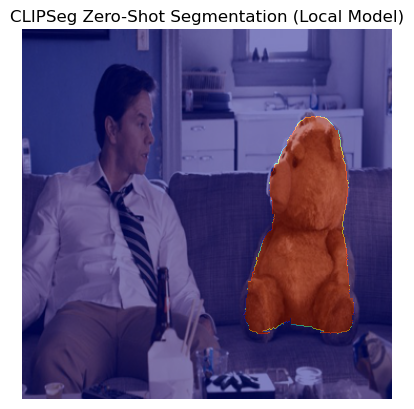

outputs.logits.shape: torch.Size([1, 352, 352])


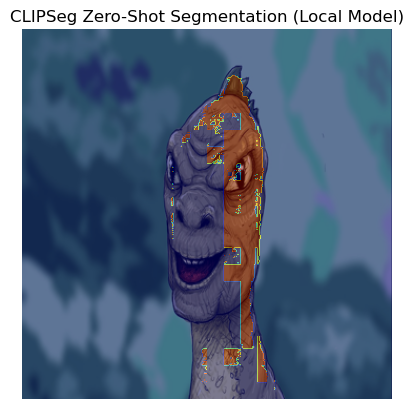

outputs.logits.shape: torch.Size([1, 352, 352])


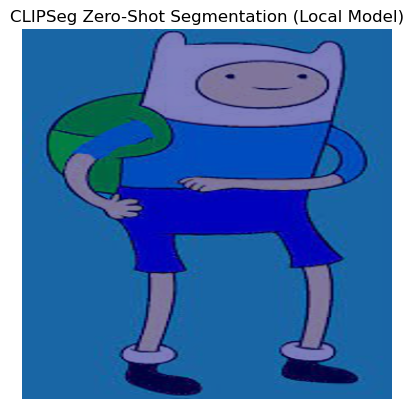

outputs.logits.shape: torch.Size([1, 352, 352])


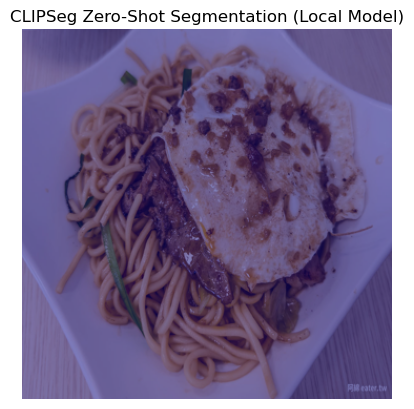

outputs.logits.shape: torch.Size([1, 352, 352])


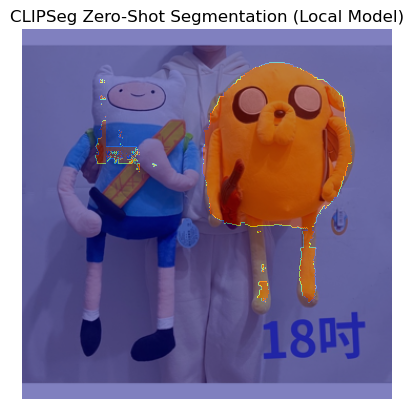

outputs.logits.shape: torch.Size([1, 352, 352])


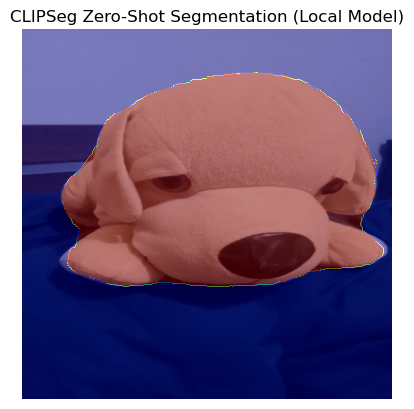

In [26]:
import torch
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import matplotlib.pyplot as plt

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 設定運算裝置
device = "cuda" if torch.cuda.is_available() else "cpu"

# 定義本地模型路徑（請根據你的模型存放位置修改此路徑）
local_model_path = "./"

# 1. 從本地載入 CLIPSeg 的處理器與模型
processor = CLIPSegProcessor.from_pretrained(local_model_path, local_files_only=True)
model = CLIPSegForImageSegmentation.from_pretrained(local_model_path, local_files_only=True).to(device)

# 2. 載入圖片並定義文字提示（根據需求修改文字描述）
for i in [0, 1, 2, 3, 4, 5, 6, 7, 36]:
    image_path = f"./{i}.jpg"  # 請將此路徑替換成你的圖片路徑
    image = Image.open(image_path).convert("RGB")
    image = image.resize((352, 352), resample=Image.BICUBIC)
    text_prompts = ["a photo of a dog"]

    # 3. 使用處理器對圖片與文字進行預處理
    inputs = processor(text=text_prompts, images=image, padding="max_length", return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 4. 進行推理以獲得分割 mask 的 logits
    with torch.no_grad():
        outputs = model(**inputs)

    # 印出 logits 的 shape 以供參考
    print("outputs.logits.shape:", outputs.logits.shape)

    # 5. 使用 sigmoid 激活 logits 得到 mask 概率圖
    mask_probs = torch.sigmoid(outputs.logits)

    # 根據 mask_probs 的 shape 決定如何取出 mask
    # 常見 shape 情況：
    # (1, 1, H, W)  -> 取 mask = mask_probs[0, 0]
    # (1, H, W)    -> 取 mask = mask_probs[0]
    if len(mask_probs.shape) == 4:
        mask = mask_probs[0, 0].cpu().numpy()
    elif len(mask_probs.shape) == 3:
        mask = mask_probs[0].cpu().numpy()
    else:
        raise ValueError(f"Unexpected mask shape: {mask_probs.shape}")

    # 6. (可選) 將概率 mask 進行閾值處理，產生二值化 mask
    binary_mask = mask > 0.5

    # 7. 視覺化原圖與分割結果
    # plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.imshow(binary_mask, alpha=0.5, cmap="jet")
    plt.title("CLIPSeg Zero-Shot Segmentation (Local Model)")
    plt.axis("off")
    plt.show()
